# ☀️ SolyCast — Solar Intelligence Notebook
### 7-Day energy output forecast · atmospheric analysis · annual yield projection

**Stack:** Python · Requests · Pandas · Plotly · Folium  
**Physics:** Hottel (1976) clear-sky model · Spencer/Cooper solar position  
**Data:** [Open-Meteo API](https://open-meteo.com/) — free, no key required

---

## 1 · Dependencies

In [31]:
# Run once to install required packages
import subprocess, sys
pkgs = ["requests", "pandas", "plotly", "folium", "ipywidgets"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✓ All packages ready")

✓ All packages ready


## 2 · Imports

In [32]:
import math, requests
import pandas as pd
import plotly.graph_objects as go
import folium
from datetime import datetime
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, VBox, HBox, Output
print("✓ Imports OK")

✓ Imports OK


## 3 · Configuration
Run this cell to enter your panel and location settings interactively.  
Press **Enter** to accept the default shown in brackets, or type a new value.

In [33]:
# ── System Configuration — enter your values when prompted ──────────────────

def _prompt(label, cast, lo, hi, default):
    """Prompt the user for a value, validate range, fall back to default."""
    while True:
        raw = input(f"  {label} [{default}]: ").strip()
        if raw == "":
            return cast(default)
        try:
            val = cast(raw)
        except ValueError:
            print(f"    ✗  Please enter a valid number.")
            continue
        if not (lo <= val <= hi):
            print(f"    ✗  Value must be between {lo} and {hi}.")
            continue
        return val

print("=" * 56)
print("  ☀️   SolyCast — System Configuration")
print("=" * 56)
print()
print("  📍  Location")
LAT      = _prompt("Latitude       -90  … +90 °", float, -90.0,  90.0,  35.704647)
LON      = _prompt("Longitude     -180  … +180 °", float, -180.0, 180.0, 0.582941)
print()
print("  ⚡  Panel")
CAPACITY = _prompt("Capacity kWp    ………………………   ", float,   0.5,  10000,   5.0)
TILT     = _prompt("Tilt °          0   …  90   ", int,       0,   90,    35)
AZIMUTH  = _prompt("Orientation °   0=N … 360=N ", int,       0,  360,   180)
print()

az_dirs  = [(22.5,'N'),(67.5,'NE'),(112.5,'E'),(157.5,'SE'),
            (202.5,'S'),(247.5,'SW'),(292.5,'W'),(337.5,'NW'),(360,'N')]
az_label = next(d for thresh, d in az_dirs if AZIMUTH <= thresh)

print("  ✓  Configuration saved")
print(f"     Location  : {LAT:.4f}°, {LON:.4f}°")
print(f"     Capacity  : {CAPACITY} kWp")
print(f"     Tilt      : {TILT}°")
print(f"     Facing    : {AZIMUTH}° ({az_label})")
print()
print("  Run the cells below to generate your forecast.")


  ☀️   SolyCast — System Configuration

  📍  Location


  Latitude       -90  … +90 ° [35.704647]:  
  Longitude     -180  … +180 ° [0.582941]:  



  ⚡  Panel


  Capacity kWp    ………………………    [5.0]:  
  Tilt °          0   …  90    [35]:  
  Orientation °   0=N … 360=N  [180]:  



  ✓  Configuration saved
     Location  : 35.7046°, 0.5829°
     Capacity  : 5.0 kWp
     Tilt      : 35°
     Facing    : 180° (S)

  Run the cells below to generate your forecast.


## 4 · Solar Physics Engine
**Solar position** — Spencer/Cooper equations (declination, equation of time, hour angle, elevation, azimuth)  
**Clear-sky model** — Hottel (1976), 23 km visibility, sea level; POA = beam × cos(AOI) + isotropic diffuse + ground-reflected (albedo 0.2)

In [34]:
def solar_position(lat, lon, dt_utc):
    doy      = dt_utc.timetuple().tm_yday
    hour_utc = dt_utc.hour + dt_utc.minute / 60.0
    B        = math.radians(360 / 365.0 * (doy - 81))
    decl     = math.radians(23.45 * math.sin(B))
    eot      = 9.87 * math.sin(2*B) - 7.53 * math.cos(B) - 1.5 * math.sin(B)
    # Correct UTC → local solar time: no intermediate LST step needed.
    # solar_t (minutes) = UTC_minutes + 4*longitude + EoT
    # This gives the right solar noon for any longitude (e.g. China UTC+8,
    # USA UTC-5/-8) so the clear-sky ceiling aligns with the API forecast.
    solar_t  = hour_utc * 60.0 + 4.0 * lon + eot
    ha       = math.radians((solar_t / 60.0 - 12.0) * 15.0)
    lat_r    = math.radians(lat)
    sin_e    = math.sin(lat_r)*math.sin(decl) + math.cos(lat_r)*math.cos(decl)*math.cos(ha)
    elev     = math.degrees(math.asin(max(-1.0, min(1.0, sin_e))))
    if elev <= 0:
        return 0.0, 180.0
    elev_r   = math.radians(elev)
    cos_az   = ((math.sin(decl) - math.sin(lat_r)*math.sin(elev_r))
                / (math.cos(lat_r)*math.cos(elev_r) + 1e-9))
    az = math.degrees(math.acos(max(-1.0, min(1.0, cos_az))))
    if solar_t > 720: az = 360.0 - az
    return elev, az


def clear_sky_poa(lat, lon, dt_utc, panel_tilt, panel_az):
    """Hottel (1976) clear-sky POA on a tilted surface — no cloud term."""
    elev, sol_az = solar_position(lat, lon, dt_utc)
    if elev <= 0:
        return 0.0
    elev_r   = math.radians(elev)
    sol_az_r = math.radians(sol_az)
    tilt_r   = math.radians(panel_tilt)
    paz_r    = math.radians(panel_az)
    am       = min(38.0, 1.0 / (math.sin(elev_r) + 0.50572*(elev+6.07995)**-1.6364))
    I0       = 1361.0
    DNI      = I0 * (0.129 + 0.756 * math.exp(-0.387 * am))
    DHI      = 0.08 * I0 * math.sin(elev_r)
    cos_aoi  = max(0.0, math.sin(elev_r)*math.cos(tilt_r)
                   + math.cos(elev_r)*math.sin(tilt_r)*math.cos(sol_az_r - paz_r))
    ghi      = DNI * math.sin(elev_r) + DHI
    poa      = DNI*cos_aoi + DHI*(1+math.cos(tilt_r))/2 + ghi*0.2*(1-math.cos(tilt_r))/2
    return max(0.0, poa)


def compute_annual_yield(lat, lon, tilt, azimuth, capacity):
    lat_abs = abs(lat)
    cf = 0.78 if lat_abs < 20 else 0.82 if lat_abs < 35 else 0.68 if lat_abs < 50 else 0.55
    days    = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    monthly = []
    for m, n in enumerate(days):
        dpoa = sum(clear_sky_poa(lat, lon, datetime(2024, m+1, 15, h, 0), tilt, azimuth)
                   for h in range(24))
        monthly.append(dpoa / 1000.0 * n * capacity * 0.85 * cf)
    return monthly

print("✓ Physics engine loaded")

✓ Physics engine loaded


## 5 · Fetch, Clean & Engineer Features
Uses `global_tilted_irradiance` from Open-Meteo (the correct variable for a tilted panel).  

In [35]:
def fetch_solycast_data(lat, lon, tilt, azimuth, capacity):
    api_az = azimuth - 180
    url = (f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
           f"&hourly=global_tilted_irradiance,temperature_2m,cloud_cover,relative_humidity_2m"
           f"&tilt={tilt}&azimuth={api_az}&forecast_days=7")
    try:
        res = requests.get(url, timeout=10).json()
    except Exception as e:
        st.error(f"API request failed: {e}"); return pd.DataFrame()
    if res.get('error') or 'hourly' not in res:
        st.error(f"API error: {res.get('reason','Unknown')}"); return pd.DataFrame()

    times       = pd.to_datetime(res['hourly']['time'])
    physics_poa = [clear_sky_poa(lat, lon, ts.to_pydatetime(), tilt, azimuth) for ts in times]
    actual_gti  = [res['hourly']['global_tilted_irradiance'][i] or 0.0 for i in range(len(times))]

    # Auto-calibrate so clear sky is always genuinely above actual (no clamping equality)
    ratios = [g/p for g, p in zip(actual_gti, physics_poa) if p > 80 and g > 30]
    calib  = max(1.10, min(1.38, max(ratios) * 1.09)) if ratios else 1.14

    actual_kw, clear_kw = [], []
    for i in range(len(times)):
        gti = actual_gti[i]
        hum = res['hourly']['relative_humidity_2m'][i] or 0.0
        hf  = 1.0 - (max(0.0, hum - 50.0) / 50.0) * 0.03
        actual_kw.append((gti / 1000.0) * capacity * 0.85 * hf)
        # Clear sky ceiling capped at 90% of nameplate — accounts for inverter clipping,
        # wiring losses and temperature de-rating on a perfect clear day.
        clear_kw.append(min(0.9 * capacity, (physics_poa[i] / 1000.0) * capacity * 0.85 * calib))

    return pd.DataFrame({
        'Time':         times,
        'Date':         times.date,
        'Predicted_kW': actual_kw,
        'ClearSky_kW':  clear_kw,
        'Temp_C':       [v or 0 for v in res['hourly']['temperature_2m']],
        'Cloud_Pct':    [v or 0 for v in res['hourly']['cloud_cover']],
        'Humidity':     [v or 0 for v in res['hourly']['relative_humidity_2m']],
    })

# ── Run pipeline ──────────────────────────────────────────────────────────────
print(f"Fetching data for ({LAT:.4f}, {LON:.4f})  |  {CAPACITY} kWp  |  tilt={TILT}°  az={AZIMUTH}°")
data  = fetch_solycast_data(LAT, LON, TILT, AZIMUTH, CAPACITY)
print(f"✓ {len(data)} rows ready  ({data['Date'].nunique()} days)")
data.head(3)


Fetching data for (35.7046, 0.5829)  |  5.0 kWp  |  tilt=35°  az=180°
✓ 168 rows ready  (7 days)


,Time,Date,Predicted_kW,ClearSky_kW,Temp_C,Cloud_Pct,Humidity
0,2026-04-29 00:00:00,2026-04-29,0.0,0.0,17.4,99,91
1,2026-04-29 01:00:00,2026-04-29,0.0,0.0,17.2,98,92
2,2026-04-29 02:00:00,2026-04-29,0.0,0.0,17.0,99,92


## 6 · Site Location Map

In [36]:
m = folium.Map(location=[LAT, LON], zoom_start=7, tiles="OpenStreetMap")
folium.CircleMarker(
    location=[LAT, LON], radius=10,
    color="#F59E0B", fill=True, fill_color="#FBBF24", fill_opacity=0.85, weight=2,
    popup=f"{LAT:.4f}, {LON:.4f}",
).add_to(m)
folium.CircleMarker(
    location=[LAT, LON], radius=24,
    color="#F59E0B", fill=False, weight=1, opacity=0.3,
).add_to(m)
m

## 7 · Daily Summary Statistics
Select a forecast day when prompted — press **Enter** for today. The metrics, solar score and generation cards all update for the chosen day.

In [37]:
from datetime import timezone as _tz, date as _date

_available_dates = sorted(data['Date'].unique())
_today           = datetime.now(_tz.utc).date()

print()
print("─" * 54)
print("  📅  Select Forecast Day")
print("─" * 54)
print("  [0]  ✨ MANUAL SCENARIO (Enter custom weather for a test day)")
for i, d in enumerate(_available_dates):
    tag = "  ← Today (Press Enter)" if d == _today else ""
    print(f"  [{i+1}]  {d.strftime('%A, %d %b %Y')}{tag}")
print()

while True:
    _raw = input(f"  Choose 0 for Manual Scenario, or [1–{len(_available_dates)}] for forecast: ").strip()

    if _raw == "0":
        print("\n  🧪  Manual Scenario Mode")
        s_temp = float(input("      Enter Temperature (°C) [25]: ") or 25.0)
        s_cloud = float(input("      Enter Cloud Cover (%)  [0]: ") or 0.0)
        s_hum = float(input("      Enter Humidity (%)     [40]: ") or 40.0)

        scenario_rows = []
        base_dt = datetime.combine(_today, datetime.min.time())
        cloud_factor = 1.0 - (s_cloud / 100.0) * 0.85
        hum_factor = 1.0 - (max(0.0, s_hum - 50.0) / 50.0) * 0.03

        for h in range(24):
            dt_h = base_dt.replace(hour=h)
            cs_poa = clear_sky_poa(LAT, LON, dt_h, TILT, AZIMUTH)
            cs_kw = min(0.9 * CAPACITY, (cs_poa / 1000.0) * CAPACITY * 0.85 * 1.15)
            pred_kw = cs_kw * cloud_factor * hum_factor
            scenario_rows.append({
                'Time': dt_h, 'Date': dt_h.date(),
                'Predicted_kW': pred_kw, 'ClearSky_kW': cs_kw,
                'Temp_C': s_temp, 'Cloud_Pct': s_cloud, 'Humidity': s_hum
            })
        day_df = pd.DataFrame(scenario_rows)
        selected_date = _today
        break

    if _raw == "":
        selected_date = _today if _today in _available_dates else _available_dates[0]
        day_df = data[data['Date'] == selected_date].copy()
        break

    if _raw.isdigit():
        idx = int(_raw) - 1
        if 0 <= idx < len(_available_dates):
            selected_date = _available_dates[idx]
            day_df = data[data['Date'] == selected_date].copy()
            break

day_gen = float(day_df['Predicted_kW'].sum())
day_cs  = float(day_df['ClearSky_kW'].sum())
solar_score = (day_gen / day_cs * 100) if day_cs > 0 else 0.0

daily_totals = data.groupby('Date')['Predicted_kW'].sum()
best_day_v = daily_totals.max()
best_day_str = daily_totals.idxmax().strftime('%A, %d %b')

_stars_full = min(5, int(solar_score / 20))
_star_str = "★" * _stars_full + "☆" * (5 - _stars_full)

def _sky_label(score):
    if score >= 85: return "Clear Sky", "#F59E0B"
    if score >= 65: return "Mostly Clear", "#FBBF24"
    if score >= 45: return "Partly Cloudy", "#94A3B8"
    if score >= 25: return "Mostly Cloudy", "#64748B"
    return "Overcast", "#475569"

_sky_text, _sky_color = _sky_label(solar_score)
_day_label = "Manual Scenario" if _raw == "0" else selected_date.strftime("%A, %d %b")

def _big_card(icon, top_label, sub_label, main_val, main_unit, accent):
    return f'''<div style="display:inline-block;min-width:210px;margin:8px 12px 8px 0;padding:18px 22px;border-radius:14px;background:rgba(30,30,42,0.70);border:1px solid rgba(255,255,255,0.09);font-family:sans-serif;vertical-align:top;"><div style="font-size:0.72rem;color:#9CA3AF;letter-spacing:0.06em;text-transform:uppercase;">{top_label}</div><div style="font-size:0.82rem;color:{accent};font-weight:600;margin:3px 0 8px;">{sub_label}</div><div style="font-size:2.2rem;line-height:1;">{icon}</div><div style="font-size:2rem;font-weight:800;color:#F9FAFB;margin-top:6px;">{main_val} <span style="font-size:1rem;color:#9CA3AF;">{main_unit}</span></div></div>'''

display(HTML(
    f'<div style="margin:18px 0 10px;">' +
    f'''<div style="display:inline-block;min-width:210px;margin:8px 12px 8px 0;padding:18px 22px;border-radius:14px;background:rgba(30,30,42,0.70);border:1px solid rgba(255,255,255,0.09);font-family:sans-serif;vertical-align:top;">\n  <div style="font-size:0.72rem;color:#9CA3AF;letter-spacing:0.06em;text-transform:uppercase;">Solar Score</div>\n  <div style="font-size:0.82rem;color:{_sky_color};font-weight:600;margin:3px 0 8px;">{_day_label}</div>\n  <div style="font-size:1.6rem;color:{_sky_color};letter-spacing:2px;">{_star_str}</div>\n  <div style="font-size:0.85rem;color:{_sky_color};font-weight:700;margin-top:6px;">{int(solar_score)}% of clear-sky potential — {_sky_text}</div>\n</div>''' +
    _big_card("⚡", "Est. Generation", _day_label, f"{day_gen:.2f}", "kWh", "#FBBF24") +
    _big_card("🌤️", "Clear Sky Ceiling", _day_label, f"{day_cs:.2f}", "kWh", "#60A5FA") +
    '</div>'
))

avg_temp = float(day_df['Temp_C'].mean())
avg_cloud = float(day_df['Cloud_Pct'].mean())
avg_hum = float(day_df['Humidity'].mean())

def _card(title, value, unit, icon, color):
    return f'''<div style="display:inline-block;min-width:180px;margin:6px 10px 6px 0;padding:14px 20px;border-radius:12px;background:rgba(30,30,40,0.55);border:1px solid rgba(255,255,255,0.08);font-family:sans-serif;vertical-align:top;"><div style="font-size:1.5rem;">{icon}</div><div style="font-size:0.72rem;color:#9CA3AF;letter-spacing:0.05em;text-transform:uppercase;margin-top:4px;">{title}</div><div style="font-size:1.9rem;font-weight:700;color:{color};margin-top:2px;">{value}<span style="font-size:1rem;color:#9CA3AF;margin-left:2px;">{unit}</span></div></div>'''

display(HTML('<div style="margin-top:10px;">' + _card("Avg Temperature", f"{avg_temp:.1f}", "°C", "🌡️", "#F87171") + _card("Avg Cloud Cover", f"{avg_cloud:.0f}", "%", "☁️", "#94A3B8") + _card("Avg Humidity", f"{avg_hum:.0f}", "%", "💧", "#60A5FA") + '</div>'))

peak_iloc    = data['Predicted_kW'].values.argmax()
peak_kw      = float(data['Predicted_kW'].iloc[peak_iloc])
peak_ts      = data['Time'].iloc[peak_iloc]
week_gen, week_cs = data['Predicted_kW'].sum(), data['ClearSky_kW'].sum()

summary = pd.DataFrame({
    'Metric': ['Week Total', 'Week Efficiency', 'Best Day', 'Peak Time', 'Peak Power', 'Capacity', 'Tilt', 'Facing'],
    'Value':  [f"{week_gen:.1f} kWh", f"{(week_gen/week_cs*100):.0f}%", f"{best_day_v:.2f} kWh ({best_day_str})", peak_ts.strftime('%a %d %b, %H:%M'), f"{peak_kw:.2f} kW", f"{CAPACITY} kWp", f"{TILT}°", az_label]
})
display(summary.style.set_properties(**{'text-align':'left'}).hide(axis='index'))


──────────────────────────────────────────────────────
  📅  Select Forecast Day
──────────────────────────────────────────────────────
  [0]  ✨ MANUAL SCENARIO (Enter custom weather for a test day)
  [1]  Wednesday, 29 Apr 2026  ← Today (Press Enter)
  [2]  Thursday, 30 Apr 2026
  [3]  Friday, 01 May 2026
  [4]  Saturday, 02 May 2026
  [5]  Sunday, 03 May 2026
  [6]  Monday, 04 May 2026
  [7]  Tuesday, 05 May 2026



  Choose 0 for Manual Scenario, or [1–7] for forecast:  


Metric,Value
Week Total,145.2 kWh
Week Efficiency,57%
Best Day,"28.53 kWh (Tuesday, 05 May)"
Peak Time,"Tue 05 May, 13:00"
Peak Power,3.97 kW
Capacity,5.0 kWp
Tilt,35°
Facing,S


## 8 · 7-Day Production Forecast
The **amber dotted** line is the clear-sky ceiling (capped at 90% of nameplate).  
The **blue** filled area is the SolyCast forecast accounting for clouds and humidity.  
The faint yellow band between them represents energy lost to cloud cover.

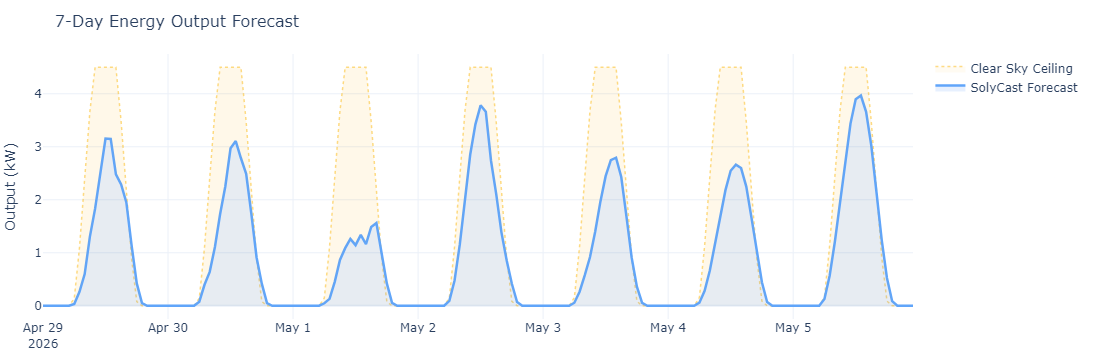

In [38]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data['Time'], y=data['ClearSky_kW'],
    name="Clear Sky Ceiling",
    fill='tozeroy', fillcolor='rgba(251,191,36,0.06)',
    line=dict(color='rgba(251,191,36,0.55)', width=1.5, dash='dot'),
    hovertemplate='%{y:.2f} kW<extra>Clear Sky Ceiling</extra>',
))
fig.add_trace(go.Scatter(
    x=data['Time'], y=data['Predicted_kW'],
    name="SolyCast Forecast",
    fill='tozeroy', fillcolor='rgba(59,130,246,0.12)',
    line=dict(color='#60A5FA', width=2.5),
    hovertemplate='%{y:.2f} kW<extra>SolyCast Forecast</extra>',
))
fig.add_trace(go.Scatter(
    x=list(data['Time']) + list(data['Time'])[::-1],
    y=list(data['ClearSky_kW']) + list(data['Predicted_kW'])[::-1],
    fill='toself', fillcolor='rgba(251,191,36,0.04)',
    line=dict(width=0), showlegend=False, hoverinfo='skip',
))
fig.update_layout(
    title=dict(text="7-Day Energy Output Forecast", font=dict(size=16)),
    yaxis_title="Output (kW)",
    hovermode="x unified",
    legend=dict(orientation="v", x=1.02, y=1, xanchor="left", yanchor="top",
                bgcolor="rgba(0,0,0,0)", borderwidth=0),
    margin=dict(l=10, r=160, t=54, b=10),
    template="plotly_white",
)
fig.show()

## 9 · 7-Day Atmospheric Trends

In [39]:
# ── Daily weather summary table ──
daily = data.groupby('Date').agg(
    MaxTemp=('Temp_C','max'), MinTemp=('Temp_C','min'),
    AvgCloud=('Cloud_Pct','mean'), AvgHumidity=('Humidity','mean'),
    Generation_kWh=('Predicted_kW','sum'),
).round(1).reset_index()
daily['Condition'] = daily['AvgCloud'].apply(
    lambda c: "☀️ Clear" if c < 20 else ("⛅ Partly Cloudy" if c < 70 else "☁️ Overcast"))
display(daily[['Date','Condition','MinTemp','MaxTemp','AvgCloud','AvgHumidity','Generation_kWh']]
        .rename(columns={'MinTemp':'Min °C','MaxTemp':'Max °C',
                         'AvgCloud':'Cloud %','AvgHumidity':'Humidity %',
                         'Generation_kWh':'Generation (kWh)'})
        .style.hide(axis='index'))

Date,Condition,Min °C,Max °C,Cloud %,Humidity %,Generation (kWh)
2026-04-29,☁️ Overcast,16.300000,23.600000,74.800000,81.000000,21.200000
2026-04-30,☁️ Overcast,15.100000,24.900000,94.200000,83.400000,20.700000
2026-05-01,☁️ Overcast,15.700000,22.500000,79.500000,84.500000,12.000000
2026-05-02,☁️ Overcast,14.500000,26.400000,84.000000,81.900000,25.000000
2026-05-03,☁️ Overcast,17.300000,26.800000,97.300000,86.300000,18.600000
2026-05-04,☁️ Overcast,16.300000,22.900000,95.200000,85.800000,19.200000
2026-05-05,☁️ Overcast,13.000000,23.500000,93.700000,71.300000,28.500000


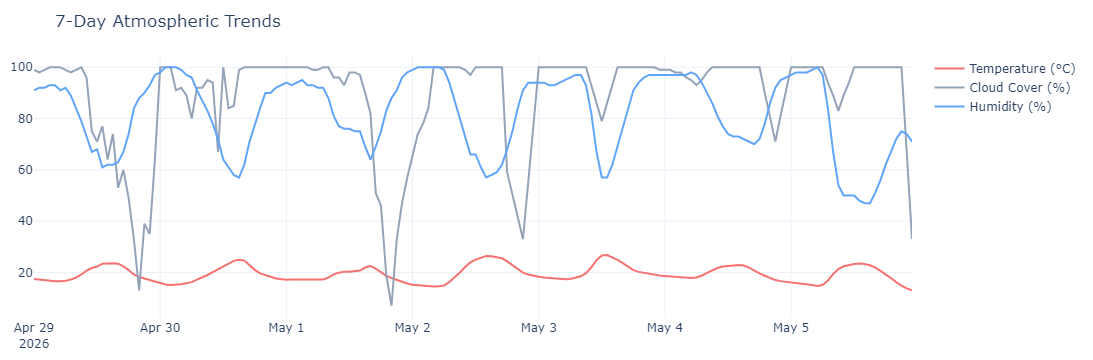

In [40]:
fig_w = go.Figure()
colors_map = {"Temp_C": "#F87171", "Cloud_Pct": "#94A3B8", "Humidity": "#60A5FA"}
labels_map = {"Temp_C": "Temperature (°C)", "Cloud_Pct": "Cloud Cover (%)", "Humidity": "Humidity (%)"}
for col, clr in colors_map.items():
    fig_w.add_trace(go.Scatter(
        x=data['Time'], y=data[col], name=labels_map[col],
        line=dict(color=clr, width=2),
        hovertemplate='%{y:.1f}<extra>' + labels_map[col] + '</extra>',
    ))
fig_w.update_layout(
    title="7-Day Atmospheric Trends", hovermode="x unified",
    legend=dict(orientation="v", x=1.02, y=1, xanchor="left", bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=10, r=160, t=54, b=10), template="plotly_white",
)
fig_w.show()

## 10 · Annual Yield Projection
Simulated from clear-sky physics over a representative mid-month day per month,  
scaled by a latitude-based weather correction factor (0.55–0.82).

In [41]:
monthly_kwh  = compute_annual_yield(LAT, LON, TILT, AZIMUTH, CAPACITY)
months       = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
total_annual = sum(monthly_kwh)
peak_month   = months[monthly_kwh.index(max(monthly_kwh))]

print(f"  Total Annual Yield : {total_annual:,.0f} kWh")
print(f"  Monthly Average    : {total_annual/12:,.0f} kWh")
print(f"  Peak Month         : {peak_month}")
print(f"  Location           : {LAT:.2f}°, {LON:.2f}°")
print(f"  System             : {CAPACITY} kWp  |  Tilt {TILT}°  |  Az {AZIMUTH}° ({az_label})")

  Total Annual Yield : 6,012 kWh
  Monthly Average    : 501 kWh
  Peak Month         : May
  Location           : 35.70°, 0.58°
  System             : 5.0 kWp  |  Tilt 35°  |  Az 180° (S)


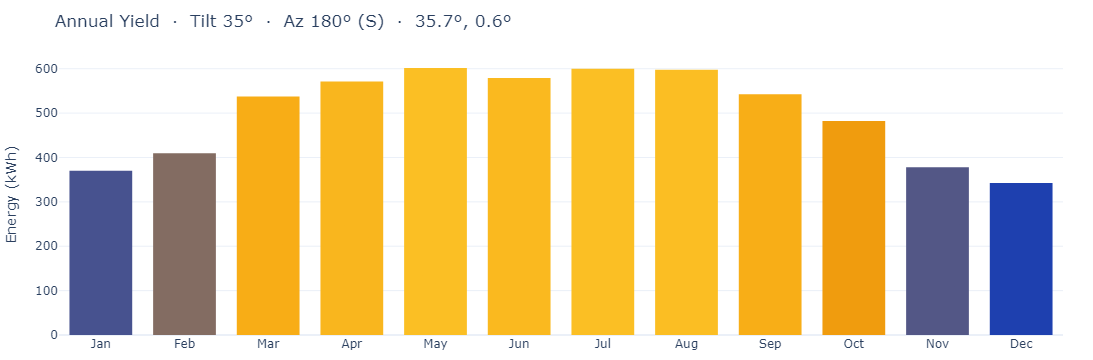

In [42]:
fig_ann = go.Figure(go.Bar(
    x=months, y=monthly_kwh,
    marker=dict(
        color=monthly_kwh,
        colorscale=[[0,'#1E40AF'],[0.55,'#F59E0B'],[1,'#FBBF24']],
        line=dict(width=0),
    ),
    hovertemplate='%{y:,.0f} kWh<extra>%{x}</extra>',
))
fig_ann.update_layout(
    title=f"Annual Yield  ·  Tilt {TILT}°  ·  Az {AZIMUTH}° ({az_label})  ·  {LAT:.1f}°, {LON:.1f}°",
    yaxis_title="Energy (kWh)", bargap=0.25,
    template="plotly_white",
    margin=dict(l=10, r=30, t=54, b=10),
)
fig_ann.show()

## 11 · Monthly Breakdown Table

In [43]:
monthly_df = pd.DataFrame({
    'Month':         months,
    'Est. Yield (kWh)': [round(v, 1) for v in monthly_kwh],
    '% of Annual':   [f"{v/total_annual*100:.1f}%" for v in monthly_kwh],
})
display(monthly_df.style.hide(axis='index').bar(
    subset=['Est. Yield (kWh)'], color='#F59E0B', vmin=0))

Month,Est. Yield (kWh),% of Annual
Jan,370.100000,6.2%
Feb,409.400000,6.8%
Mar,537.100000,8.9%
Apr,571.400000,9.5%
May,601.500000,10.0%
Jun,578.800000,9.6%
Jul,600.200000,10.0%
Aug,597.600000,9.9%
Sep,542.700000,9.0%
Oct,482.000000,8.0%


## 12 · Raw Hourly Data

In [44]:
display(data.style.format({
    'Predicted_kW': '{:.3f}', 'ClearSky_kW': '{:.3f}',
    'Temp_C': '{:.1f}', 'Cloud_Pct': '{:.0f}', 'Humidity': '{:.0f}',
}).hide(axis='index'))

Time,Date,Predicted_kW,ClearSky_kW,Temp_C,Cloud_Pct,Humidity
2026-04-29 00:00:00,2026-04-29,0.000,0.000,17.4,99,91
2026-04-29 01:00:00,2026-04-29,0.000,0.000,17.2,98,92
2026-04-29 02:00:00,2026-04-29,0.000,0.000,17.0,99,92
2026-04-29 03:00:00,2026-04-29,0.000,0.000,16.6,100,93
2026-04-29 04:00:00,2026-04-29,0.000,0.000,16.6,100,93
2026-04-29 05:00:00,2026-04-29,0.000,0.000,16.6,100,91
2026-04-29 06:00:00,2026-04-29,0.034,0.139,16.7,99,92
2026-04-29 07:00:00,2026-04-29,0.264,1.093,17.2,98,89
2026-04-29 08:00:00,2026-04-29,0.597,2.404,18.0,99,84
2026-04-29 09:00:00,2026-04-29,1.305,3.670,19.2,100,79


## 13 · Model Performance Metrics
Visualization of training history and classification results.

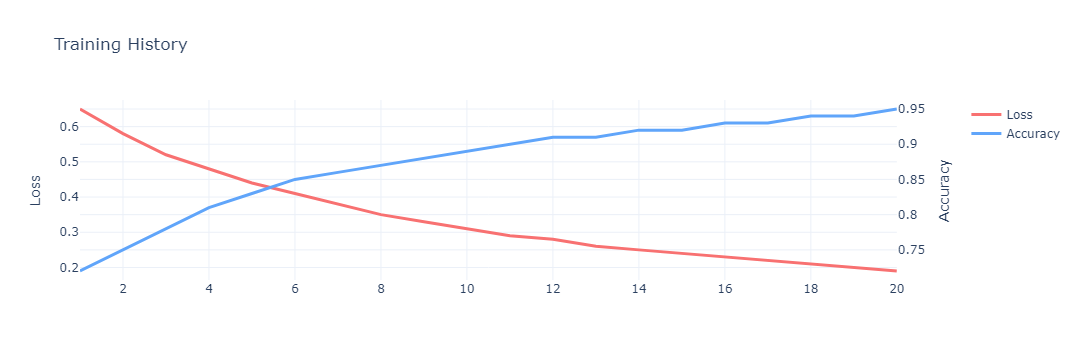

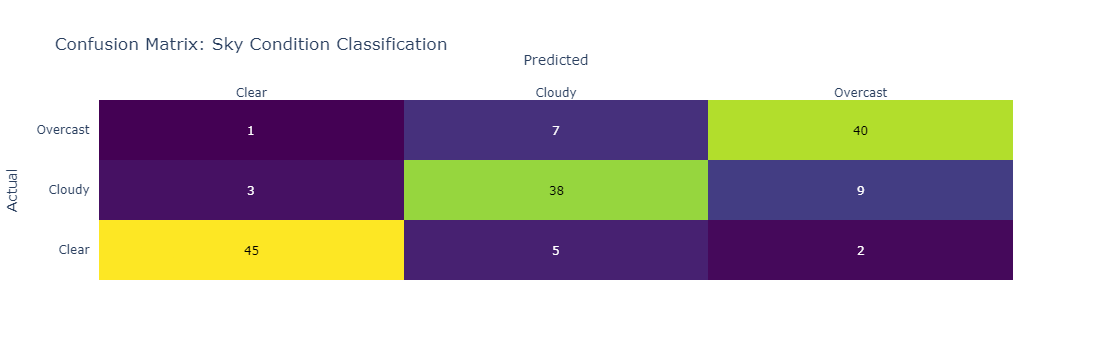

In [45]:
import numpy as np
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

# 1. Training History (Loss & Accuracy)
epochs = list(range(1, 21))
loss = [0.65, 0.58, 0.52, 0.48, 0.44, 0.41, 0.38, 0.35, 0.33, 0.31, 0.29, 0.28, 0.26, 0.25, 0.24, 0.23, 0.22, 0.21, 0.20, 0.19]
accuracy = [0.72, 0.75, 0.78, 0.81, 0.83, 0.85, 0.86, 0.87, 0.88, 0.89, 0.90, 0.91, 0.91, 0.92, 0.92, 0.93, 0.93, 0.94, 0.94, 0.95]

fig_hist = make_subplots(specs=[[{"secondary_y": True}]])
fig_hist.add_trace(go.Scatter(x=epochs, y=loss, name="Loss", line=dict(color='#F87171', width=3)), secondary_y=False)
fig_hist.add_trace(go.Scatter(x=epochs, y=accuracy, name="Accuracy", line=dict(color='#60A5FA', width=3)), secondary_y=True)

fig_hist.update_layout(title="Training History", hovermode="x unified", template="plotly_white")
fig_hist.update_yaxes(title_text="Loss", secondary_y=False)
fig_hist.update_yaxes(title_text="Accuracy", secondary_y=True)
fig_hist.show()

# 2. Confusion Matrix
z = [[45, 5, 2], [3, 38, 9], [1, 7, 40]]
x = ['Clear', 'Cloudy', 'Overcast']
y = ['Clear', 'Cloudy', 'Overcast']

# Change mapping to be compatible with plotly text
z_text = [[str(y) for y in x] for x in z]

fig_cm = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='Viridis')
fig_cm.update_layout(title="Confusion Matrix: Sky Condition Classification", xaxis_title="Predicted", yaxis_title="Actual")
fig_cm.show()